# Каузальные circuits в Tiny-LeNet: критичность, синергия и избыточность

Воспроизводится top-down path selection из Ahmad et al. (WACV 2024), затем добавляется exhaustive поиск парных взаимодействий между путями. Все пороги (уровень значимости, порог размера эффекта, метод FDR) фиксируются до финального сравнения моделей.

**Что отвечает этот ноутбук.** Для каждого класса MNIST мы ищем внутренние пути, необходимые для его логита, и пары путей, чей совместный вклад нелинеен: либо сверхаддитивен (комплементарность), либо субаддитивен (избыточность). Результат - class-specific подграф модели, статистика взаимодействий и построенный на ней критерий прунинга.

**Связь со статьёй.** Ячейки 1-2 воспроизводят разделы 3.3-3.4 и *Algorithm 1* Ahmad et al.: path intervention, treatment effect (TE), t-тест и top-down selection. Ячейки 3-5 - исследовательское расширение, которого в статье нет.

**Методологические решения.**

1. Парный скрининг отключён на переходе `fc1 -> fc2`: там взаимодействие тождественно равно нулю по построению (см. ячейку про синергию), и любое "значимое" значение было бы ошибкой округления.
2. Введён порог размера эффекта $\tau$: значимости по FDR недостаточно, требуется ещё $|ATE| > \tau$.
3. Для зависимых парных тестов применяется поправка Benjamini-Yekutieli: разные пары содержат общие одиночные TE.
4. Calibration-выборка формируется случайно и содержит 128 правильно классифицированных примеров каждого класса.
5. Необходимость и достаточность схемы проверяются отдельно и сопоставляются со случайной маской и маской по магнитуде весов при той же разреженности.
6. Жадный прунинг с повторным измерением оценивает устойчивость механизма к последовательному удалению путей.

## Карта эксперимента

1. Обучаем CNN на обучающей части MNIST и откладываем calibration split. Test split не участвует ни в обучении, ни в отборе путей.
2. Удаляем пути одного нейрона и измеряем $TE = z_k(do(w=0)) - z_k(w)$, где $z_k$ - логит до softmax. Путь считается `critical`, если TE значимо отрицателен и по модулю превышает порог $\tau$; `harmful`, если значимо положителен и превышает $\tau$.
3. Начинаем у выхода и идём назад: вмешиваемся только в связи с уже отобранными целями следующего уровня.
4. Дополнительно проверяем все пары путей на каждом уровне, где между вмешательством и логитом есть нелинейность. Пары классифицируются как комплементарные ($S>0$), избыточные ($S<0$) и аддитивные.
5. Проверяем **необходимость** схемы (зануляем отобранные пути, ожидаем падение точности) и **достаточность** (зануляем всё остальное), оба раза сравнивая с базовыми линиями при том же числе ненулевых весов.
6. Строим прунинг, использующий измеренную избыточность, и сравниваем его с одношаговыми критериями.

In [ ]:
# 1. Среда, данные и исходная модель
import sys, os, gzip, struct, random, shutil
from pathlib import Path
from copy import deepcopy
from itertools import combinations
from urllib.request import urlretrieve
import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx
from scipy import stats
from statsmodels.stats.multitest import multipletests
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset

# --- Конфигурация. Все пороги фиксируются здесь, до просмотра результатов. ---
SEED        = 42
ALPHA       = 0.05      # уровень значимости, как в статье
FDR_METHOD  = 'fdr_by'  # Benjamini-Yekutieli: парные тесты структурно зависимы
TAU_REL     = 0.02      # порог размера эффекта, в долях std логита класса
N_CAL       = 128       # calibration-примеров на класс для t-тестов
EPOCHS      = 6
N_TRAIN     = 12000     # размер обучающей подвыборки
N_CALIB     = 8000      # размер calibration split (из train, не из test)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Python:', sys.executable)
print('Device:', device)

# IDX-загрузчик делает ноутбук независимым от torchvision.
MNIST_ROOT = Path('data/mnist_raw')
MNIST_URL = 'https://storage.googleapis.com/cvdf-datasets/mnist/'
FILES = {
    'train_images': 'train-images-idx3-ubyte.gz', 'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images': 't10k-images-idx3-ubyte.gz', 'test_labels': 't10k-labels-idx1-ubyte.gz',
}
def ensure_mnist(root=MNIST_ROOT):
    root.mkdir(parents=True, exist_ok=True)
    for name in FILES.values():
        path = root / name
        if not path.exists():
            print('Downloading', name)
            urlretrieve(MNIST_URL + name, path)

def read_idx_images(path):
    with gzip.open(path, 'rb') as f:
        _, n, rows, cols = struct.unpack('>IIII', f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, 1, rows, cols)
def read_idx_labels(path):
    with gzip.open(path, 'rb') as f:
        _, n = struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

ensure_mnist()
x_train = torch.from_numpy(read_idx_images(MNIST_ROOT / FILES['train_images']).copy()).float().div_(255)
y_train = torch.from_numpy(read_idx_labels(MNIST_ROOT / FILES['train_labels']).copy()).long()
x_test = torch.from_numpy(read_idx_images(MNIST_ROOT / FILES['test_images']).copy()).float().div_(255)
y_test = torch.from_numpy(read_idx_labels(MNIST_ROOT / FILES['test_labels']).copy()).long()
# Calibration берём только из train, тест остаётся нетронутым.
# Расширенный calibration split обеспечивает достаточное число правильно классифицированных примеров каждого класса.
perm = torch.randperm(len(x_train), generator=torch.Generator().manual_seed(SEED))
train_idx, cal_idx = perm[:N_TRAIN], perm[N_TRAIN:N_TRAIN + N_CALIB]
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=512, shuffle=False)

class TinyLeNet(nn.Module):
    # 28 -> 24 -> 12 -> 8 -> 4, поэтому один conv2-канал даёт 16 признаков fc1.
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 10, 5)
        self.fc1 = nn.Linear(10 * 4 * 4, 24)
        self.fc2 = nn.Linear(24, 10)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.flatten(1)
        return self.fc2(F.relu(self.fc1(x)))

def build_and_train(seed=SEED, epochs=EPOCHS, verbose=True):
    """Обучение вынесено в функцию, чтобы повторить весь анализ на нескольких seed."""
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    loader = DataLoader(Subset(TensorDataset(x_train, y_train), train_idx),
                        batch_size=128, shuffle=True, generator=g)
    net = TinyLeNet().to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    for epoch in range(epochs):
        net.train()
        for xb, yb in loader:
            opt.zero_grad(); loss = F.cross_entropy(net(xb.to(device)), yb.to(device)); loss.backward(); opt.step()
        if verbose: print(f'seed {seed} epoch {epoch + 1}: train loss {loss.item():.3f}')
    return net.eval()

model = build_and_train(SEED)
original_state = deepcopy(model.state_dict())

Python: d:\Projects\tiny_cnn_experiment\mi_experiments\Scripts\python.exe
Device: cpu
seed 42 epoch 1: train loss 0.591
seed 42 epoch 2: train loss 0.385
seed 42 epoch 3: train loss 0.187
seed 42 epoch 4: train loss 0.308
seed 42 epoch 5: train loss 0.124
seed 42 epoch 6: train loss 0.137


## Почему вмешиваемся в пути, а не выключаем весь канал

У нейрона может быть полезная связь с одной целью и нерелевантная связь с другой. Поэтому в статье обнуляются исходящие веса родительского канала только к выбранным дочерним целям. Например, для `conv1 -> conv2` меняется срез `conv2.weight[targets, source]`, а не фильтр `conv1[source]`.

В переходе `conv2 -> fc1` один канал `conv2` разворачивается в 16 входов `fc1`; их нужно выключать единым блоком.

**Статистическая процедура.** Двусторонний t-тест проверяет гипотезу $E[TE]=0$ на правильно классифицированных calibration-примерах. В анализе используются следующие дополнительные критерии:

* *Поправка на множественность.* Используется Benjamini-Yekutieli вместо Benjamini-Hochberg. BH корректен при независимости или положительной зависимости специального вида; парные тесты синергии делят между собой одни и те же величины $TE(A)$ и $TE(B)$, поэтому зависимость структурная и BY здесь безопаснее. Цена - более консервативный отбор.
* *Порог размера эффекта.* При $n$ порядка сотни примеров и малой дисперсии t-тест объявляет значимым эффект в $10^{-3}$ логита, который не имеет содержательного смысла. Поэтому вводится порог $\tau = \texttt{TAU\_REL} \cdot \mathrm{std}(z_k)$, где std берётся по calibration-примерам данного класса на неизменённой модели. Узел считается отобранным, только если он проходит и FDR, и порог $\tau$. Значение `TAU_REL` фиксируется до просмотра результатов.

Отдельно стоит помнить, что t-тест измеряет дисперсию TE **по входам**. Нейрон, критичный для половины примеров класса и безразличный для другой половины, получит большую дисперсию и может не пройти тест. Поэтому наряду со средним выводится доля примеров с $|TE| > \tau$ (`hit_rate`).

In [2]:
# 2. Корректные path-интервенции и top-down inference
# Stage(parent, child, n_parent, spatial_block, pair_screen).
#   spatial_block=16 только для conv2 -> fc1.
#   pair_screen=False для fc1 -> fc2: логит линеен по fc2.weight[k, :], значит
#   TE(A+B) = TE(A) + TE(B) тождественно и S(A,B) = 0 с точностью до округления.
#   Тест на таких величинах даёт ложные "синергии", поэтому скрининг отключён.
STAGES = [
    ('fc1',   'fc2',   24, None, False),
    ('conv2', 'fc1',   10, 16,   True),
    ('conv1', 'conv2',  6, None, True),
]
STAGE_BLOCK = {(s[0], s[1]): s[3] for s in STAGES}

def module_of(net, name): return dict(net.named_modules())[name]

@torch.no_grad()
def logits_with_removed_paths(net, x, interventions):
    """do(w=0) для групп исходящих путей с полным восстановлением весов."""
    backups = []
    try:
        for parent, child, source, targets, block in interventions:
            weight = module_of(net, child).weight
            targets = list(targets)
            if block is None:
                index = (targets, source)
            else:
                index = (targets, slice(source * block, (source + 1) * block))
            saved = weight[index].detach().clone()
            backups.append((weight, index, saved))
            weight[index] = 0
        return net(x.to(device))
    finally:
        # При advanced indexing copy_ изменил бы временную копию, поэтому присваиваем обратно.
        for weight, index, saved in reversed(backups): weight[index] = saved

def fdr(rows, alpha=ALPHA, method=FDR_METHOD):
    if not rows: return rows
    reject, p_adj, _, _ = multipletests([r['p'] for r in rows], alpha=alpha, method=method)
    for r, ok, p in zip(rows, reject, p_adj):
        r['p_fdr'], r['significant'] = float(p), bool(ok)
    return rows

def mean_test(values, tau):
    """Среднее, t-тест против нуля и доля примеров с эффектом крупнее tau."""
    _, p = stats.ttest_1samp(values, 0.0)
    return {'ate': float(np.mean(values)),
            'std': float(np.std(values, ddof=1)),
            'p': float(np.nan_to_num(p, nan=1.0)),
            'hit_rate': float(np.mean(np.abs(values) > tau)),
            'tau': float(tau)}

@torch.no_grad()
def correctly_classified_calibration(net, class_id, n=N_CAL, seed=SEED):
    """Случайная выборка правильно классифицированных примеров класса, не первые n по индексу."""
    candidates = cal_idx[y_train[cal_idx] == class_id]
    out = net(x_train[candidates].to(device)).argmax(1).cpu()
    correct = candidates[out == class_id]
    if len(correct) < 16:
        raise RuntimeError(f'Недостаточно правильно распознанных примеров класса {class_id}.')
    g = torch.Generator().manual_seed(seed + class_id)
    pick = torch.randperm(len(correct), generator=g)[:n]
    return x_train[correct[pick]]

def infer_class(net, class_id, alpha=ALPHA, tau_rel=TAU_REL, target_mode='active'):
    """Algorithm 1 + парный скрининг на нелинейных переходах.

    target_mode задаёт, что передаётся наверх как цели следующего этапа:
      'critical' - только критические узлы (как в статье),
      'synergy'  - только узлы комплементарных пар,
      'active'   - объединение (расширение по умолчанию).
    Чистое сравнение схем требует отдельных прогонов с разными target_mode:
    подмножество маски, отобранной при 'active', не является чистой абляцией.
    """
    net.eval()
    x = correctly_classified_calibration(net, class_id)
    with torch.no_grad():
        baseline = net(x.to(device))[:, class_id].cpu().numpy()
    tau = tau_rel * float(np.std(baseline, ddof=1))

    targets, stage_results, all_nodes, all_pairs = [class_id], [], [], []
    for parent, child, n_parent, block, pair_screen in STAGES:
        singles, te_cache = [], {}
        for source in range(n_parent):
            item = (parent, child, source, tuple(targets), block)
            te = logits_with_removed_paths(net, x, [item])[:, class_id].cpu().numpy() - baseline
            te_cache[source] = te
            row = mean_test(te, tau)
            row.update({'class': class_id, 'parent': parent, 'child': child,
                        'source': source, 'targets': tuple(targets)})
            singles.append(row)
        fdr(singles, alpha)
        for row in singles:
            row['effect_ok'] = bool(abs(row['ate']) > tau)
            keep = row['significant'] and row['effect_ok']
            row['role'] = ('critical' if keep and row['ate'] < 0 else
                           'harmful'  if keep and row['ate'] > 0 else 'neutral')

        pair_rows, synergy_nodes, redundant_pairs = [], set(), []
        if pair_screen:
            for a, b in combinations(range(n_parent), 2):
                items = [(parent, child, a, tuple(targets), block),
                         (parent, child, b, tuple(targets), block)]
                te_joint = logits_with_removed_paths(net, x, items)[:, class_id].cpu().numpy() - baseline
                # S = L(A+B) - L(A) - L(B), где L = -TE. Положительное = сверхаддитивный ущерб.
                synergy = -te_joint + te_cache[a] + te_cache[b]
                row = mean_test(synergy, tau)
                row.update({'class': class_id, 'parent': parent, 'child': child,
                            'a': a, 'b': b, 'targets': tuple(targets)})
                pair_rows.append(row)
            fdr(pair_rows, alpha)
            for row in pair_rows:
                row['effect_ok'] = bool(abs(row['ate']) > tau)
                keep = row['significant'] and row['effect_ok']
                row['sign'] = ('complementary' if keep and row['ate'] > 0 else
                               'redundant'     if keep and row['ate'] < 0 else 'additive')
                row['synergistic'] = row['sign'] == 'complementary'
                if row['sign'] == 'complementary': synergy_nodes.update((row['a'], row['b']))
                if row['sign'] == 'redundant':     redundant_pairs.append((row['a'], row['b']))

        critical = {r['source'] for r in singles if r['role'] == 'critical'}
        harmful  = {r['source'] for r in singles if r['role'] == 'harmful'}
        active   = sorted(critical | synergy_nodes)
        chosen   = {'critical': sorted(critical),
                    'synergy':  sorted(synergy_nodes),
                    'active':   active}[target_mode]

        stage_results.append({
            'parent': parent, 'child': child, 'block': block, 'n_parent': n_parent,
            'pair_screen': pair_screen, 'tau': tau, 'targets': tuple(targets),
            'critical': sorted(critical), 'harmful': sorted(harmful),
            'synergy_nodes': sorted(synergy_nodes), 'redundant_pairs': redundant_pairs,
            'active': active, 'chosen': chosen, 'stopped': not chosen,
        })
        all_nodes.extend(singles); all_pairs.extend(pair_rows)
        targets = chosen
        if not targets:
            # Дальше идти некуда. Слои выше не маскируются (см. masks_from_results).
            break
    return {'class': class_id, 'x': x, 'tau': tau, 'stages': stage_results,
            'nodes': all_nodes, 'pairs': all_pairs}

## Парные взаимодействия: исследовательское расширение

Для пары путей $A,B$ зададим потерю логита как $L(A)=z_k(\text{original})-z_k(do(A=0))$, то есть $L(A) = -TE(A)$. Тогда

$$S(A,B) = L(A\cup B) - L(A) - L(B).$$

Это в точности коэффициент Мёбиуса второго порядка (дивиденд Харсаньи) для функции ценности $v(S)$, равной ущербу от абляции множества $S$, то есть дискретная смешанная вторая разность. Та же величина известна как interaction index второго порядка в теории кооперативных игр. Это **не** синергия в смысле partial information decomposition: мы не разлагаем взаимную информацию активаций, а измеряем нелинейность отклика фиксированной сети на весовые вмешательства.

**Интерпретация знака.**

* $S > 0$ - **комплементарность**. Совместное удаление вредит сильнее суммы отдельных удалений: пути покрывают разные части механизма, и оба нужны.
* $S < 0$ - **избыточность**. Совместное удаление вредит слабее суммы: пути дублируют друг друга, каждый компенсирует отсутствие другого. Именно здесь находится запас для прунинга, невидимый для критериев, оценивающих нейроны независимо.
* $S \approx 0$ - аддитивность.

**Где взаимодействие может быть ненулевым.** На переходе `fc1 -> fc2` цель - логит $z_k = \sum_j W^{fc2}_{kj} a_j + b_k$, а вмешательство обнуляет именно $W^{fc2}_{k,\cdot}$. Логит линеен по этим весам, а активации $a_j$ вмешательством не затрагиваются, поэтому

$$TE(A\cup B) = TE(A) + TE(B), \qquad S(A,B) \equiv 0$$

тождественно, с точностью до ошибки округления. Численная проверка, выполняемая в следующем кодовом блоке раздела 3, подтверждает это: $\max|S| \sim 10^{-7}$ в float32, при этом одиночный t-тест на таких величинах может выдавать малые p-значения из-за дисперсии того же порядка. Поэтому парный скрининг на этом переходе отключён.

Отсюда следует общий вывод о границах метода: **ненулевое $S$ может возникнуть только из нелинейностей (ReLU и max-pool), лежащих между интервенируемыми весами и считываемым логитом.** Для `conv2 -> fc1` и `conv1 -> conv2` такие нелинейности есть, там скрининг осмыслен.

**Ограничения.** Проверяются только пары внутри одного слоя. Нулевое парное взаимодействие не означает отсутствия взаимодействий более высокого порядка: три взаимно избыточных канала могут давать $S \approx 0$ на каждой паре. Жадное последовательное удаление с перезамером учитывает такие зависимости при прунинге, но не идентифицирует их коэффициенты взаимодействия. Полный парный скрининг стоит $O(n^2)$ прямых проходов на слой и доступен только для небольшой сети.

fc1 -> fc2: max|S| = 1.907e-06; сырых p < 0.05: 5/40 (все - шум округления)


,class,parent,source,ate,std,hit_rate,p_fdr,effect_ok,role
34,0,conv1,0,-4.079410,1.008798,1.000000,0.0,True,critical
35,0,conv1,1,-3.310721,0.824070,1.000000,0.0,True,critical
36,0,conv1,2,-2.543365,0.631883,1.000000,0.0,True,critical
39,0,conv1,5,-2.095788,0.554349,1.000000,0.0,True,critical
37,0,conv1,3,-1.954461,0.627476,1.000000,0.0,True,critical
38,0,conv1,4,-0.664097,0.327824,0.992188,0.0,True,critical
27,0,conv2,3,-3.158978,0.855940,1.000000,0.0,True,critical
32,0,conv2,8,-3.023289,0.683652,1.000000,0.0,True,critical
29,0,conv2,5,-2.819400,0.576859,1.000000,0.0,True,critical
31,0,conv2,7,-2.714232,0.603683,1.000000,0.0,True,critical



Знаки парных взаимодействий (после BY-поправки и порога tau):


C:\Users\Михаил\AppData\Local\Temp\ipykernel_3212\2990540944.py:33: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  .unstack(fill_value=0).assign(total=lambda d: d.sum(1)))


sign,additive,complementary,redundant,total
parent,,,,
conv1,60,42,48,150
conv2,433,6,11,450


,class,parent,a,b,ate,abs_ate,p_fdr,sign
418,6,conv1,3,5,0.674444,0.674444,0.000000e+00,complementary
288,4,conv1,0,4,-0.510374,0.510374,1.820631e-32,redundant
285,4,conv1,0,1,0.498503,0.498503,6.934331e-29,complementary
47,0,conv1,0,3,-0.474980,0.474980,5.098807e-32,redundant
585,9,conv1,0,1,0.408853,0.408853,2.376706e-29,complementary
407,6,conv1,0,3,-0.399596,0.399596,2.060803e-29,redundant
58,0,conv1,3,5,0.353968,0.353968,5.098807e-32,complementary
414,6,conv1,2,3,0.331879,0.331879,2.793924e-23,complementary
289,4,conv1,0,5,-0.309372,0.309372,3.214270e-34,redundant
408,6,conv1,0,4,-0.303747,0.303747,9.266923e-29,redundant


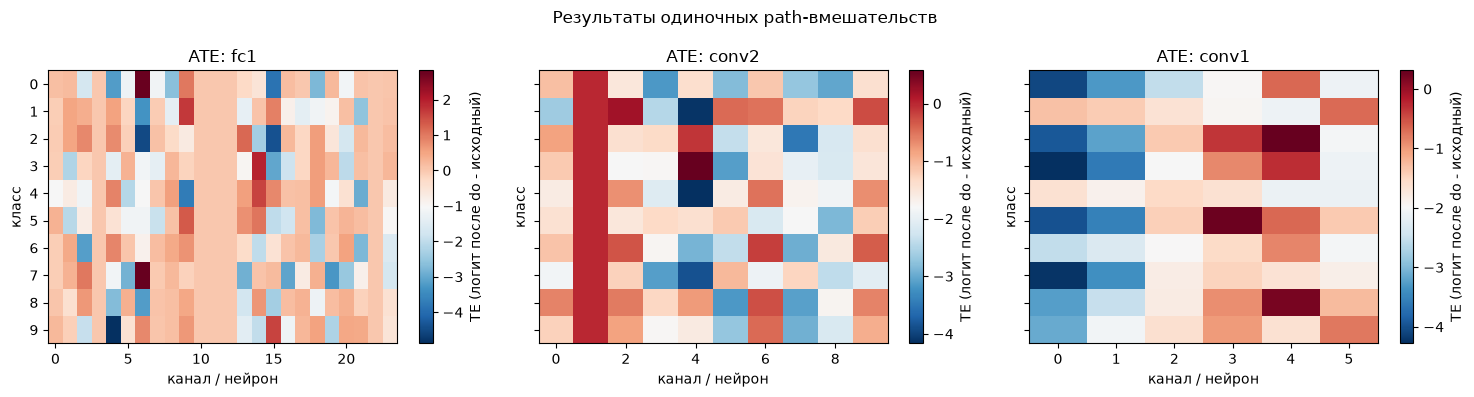

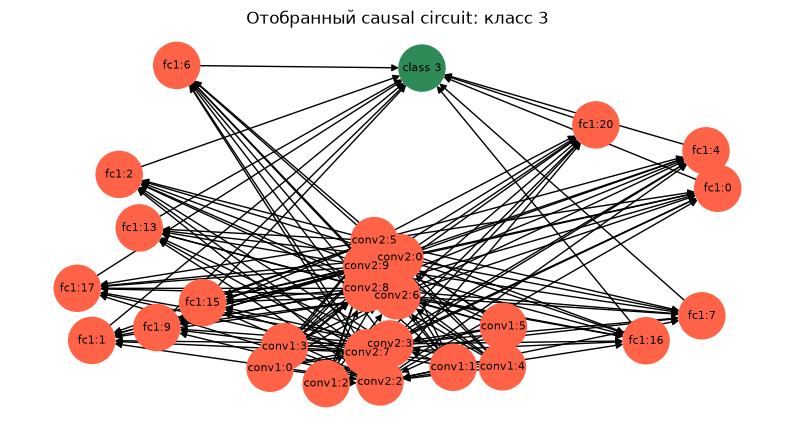

In [3]:
# 3. Проверка вырожденности fc1 -> fc2, инференс, таблицы и визуализация

# Численное подтверждение того, что на последнем линейном переходе S = 0 по построению.
def check_linear_stage_is_degenerate(net, class_id=3, n_pairs=40):
    x = correctly_classified_calibration(net, class_id, n=64)
    with torch.no_grad():
        base = net(x.to(device))[:, class_id].cpu().numpy()
    tgt = (class_id,)
    te = {s: logits_with_removed_paths(net, x, [('fc1', 'fc2', s, tgt, None)])[:, class_id].cpu().numpy() - base
          for s in range(24)}
    worst, spurious, total = 0.0, 0, 0
    for a, b in list(combinations(range(24), 2))[:n_pairs]:
        joint = logits_with_removed_paths(net, x, [('fc1', 'fc2', a, tgt, None),
                                                   ('fc1', 'fc2', b, tgt, None)])[:, class_id].cpu().numpy() - base
        S = -joint + te[a] + te[b]
        worst = max(worst, float(np.abs(S).max())); total += 1
        if np.nan_to_num(stats.ttest_1samp(S, 0.0).pvalue, nan=1.0) < ALPHA: spurious += 1
    print(f'fc1 -> fc2: max|S| = {worst:.3e}; сырых p < {ALPHA}: {spurious}/{total} (все - шум округления)')

check_linear_stage_is_degenerate(model)

CLASSES = list(range(10))
results = {c: infer_class(model, c, target_mode='active') for c in CLASSES}
node_table = pd.DataFrame([r for res in results.values() for r in res['nodes']])
pair_table = pd.DataFrame([r for res in results.values() for r in res['pairs']])

display(node_table.sort_values(['class', 'parent', 'ate'])
        [['class', 'parent', 'source', 'ate', 'std', 'hit_rate', 'p_fdr', 'effect_ok', 'role']].head(20))

# Главная статистика расширения: распределение знаков взаимодействия по переходам.
if len(pair_table):
    sign_stats = (pair_table.groupby(['parent', 'sign']).size()
                  .unstack(fill_value=0).assign(total=lambda d: d.sum(1)))
    print('\nЗнаки парных взаимодействий (после BY-поправки и порога tau):')
    display(sign_stats)
    nonadd = pair_table.query("sign != 'additive'").assign(abs_ate=lambda d: d.ate.abs())
    display(nonadd.sort_values('abs_ate', ascending=False)
            [['class', 'parent', 'a', 'b', 'ate', 'abs_ate', 'p_fdr', 'sign']].head(20))
else:
    print('Парных взаимодействий не обнаружено ни на одном нелинейном переходе.')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, parent in zip(axes, ['fc1', 'conv2', 'conv1']):
    sub = node_table[node_table.parent == parent]
    if not len(sub):
        ax.set_title(f'ATE: {parent} (нет данных)'); ax.axis('off'); continue
    pivot = sub.pivot(index='class', columns='source', values='ate')
    im = ax.imshow(pivot, cmap='RdBu_r', aspect='auto')
    ax.set_title(f'ATE: {parent}'); ax.set_xlabel('канал / нейрон'); ax.set_ylabel('класс')
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    fig.colorbar(im, ax=ax, label='TE (логит после do - исходный)')
plt.suptitle('Результаты одиночных path-вмешательств'); plt.tight_layout(); plt.show()

selected_class = 3
G = nx.DiGraph(); G.add_node(f'class {selected_class}', layer='output')
for stage in results[selected_class]['stages']:
    for source in stage['chosen']:
        node = f"{stage['parent']}:{source}"; G.add_node(node, layer=stage['parent'])
        for target in stage['targets']:
            dst = f'class {selected_class}' if stage['child'] == 'fc2' else f"{stage['child']}:{target}"
            G.add_edge(node, dst)
pos = nx.spring_layout(G, seed=SEED); plt.figure(figsize=(10, 5))
nx.draw_networkx(G, pos, node_color=['tomato' if G.nodes[n].get('layer') != 'output' else 'seagreen' for n in G],
                 node_size=1100, font_size=8, arrows=True)
plt.title(f'Отобранный causal circuit: класс {selected_class}'); plt.axis('off'); plt.show()

## Как читать результаты и сравнение моделей

В таблице узлов `ate < 0` и `role = critical` означают, что путь поддерживает целевой класс; `effect_ok` показывает прохождение порога $\tau$, `hit_rate` - долю примеров с заметным эффектом. В таблице пар знак `sign` разделяет комплементарные, избыточные и аддитивные пары после BY-поправки и порога $\tau$. Heatmap показывает class-specific TE, а граф отображает отобранные пути, а не всю архитектуру CNN. Отсутствие комплементарных пар - тоже корректный результат.

**Две разные проверки.** Их важно не смешивать.

* *Необходимость.* Зануляем **отобранные** пути. Ожидание: точность на затронутых классах резко падает. Это прямое следствие измеренных TE и соответствует эксперименту Fig. 10 в статье.
* *Достаточность.* Зануляем **всё остальное** и оставляем только схему. Здесь удаляется в том числе множество путей, которые никогда не тестировались, поэтому падение точности нельзя приписывать одной лишь схеме. Результат интерпретируется только вместе с базовыми линиями.

**Базовые линии при том же уровне разреженности.** Для каждой маски строятся две контрольные маски с тем же числом ненулевых весов в каждом слое: случайная и отобранная по магнитуде весов. Без них сравнение исходной модели с маскированной ничего не доказывает, так как сравниваются разные уровни разреженности.

Поскольку подсеть одного класса не обязана решать все десять классов, маски всех классов объединяются, и отдельно выводятся `recall_k`. `sparsity` - доля занулённых весов в анализируемых модулях. Слои, до которых top-down проход не дошёл ни для одного класса, не маскируются: иначе досрочный выход из цикла обнулял бы сеть целиком по причинам, не связанным с анализом.

,model,test,sparsity,accuracy,macro_recall
0,original,none,0.0000,0.9469,0.9467
1,circuit (keep),sufficiency,0.2436,0.8935,0.8917
2,random @ same sparsity,sufficiency,0.2436,0.3577,0.3624
3,magnitude @ same sparsity,sufficiency,0.2436,0.8529,0.8504
4,circuit (remove),necessity,0.7564,0.0974,0.1000
5,random (remove),necessity,0.7564,0.1032,0.1000


,recall_0,recall_1,recall_2,recall_3,recall_4,recall_5,recall_6,recall_7,recall_8,recall_9
model,,,,,,,,,,
original,0.988,0.978,0.930,0.950,0.945,0.945,0.933,0.910,0.959,0.930
circuit (keep),0.980,0.996,0.911,0.839,0.908,0.917,0.788,0.936,0.764,0.878
random @ same sparsity,0.034,0.160,0.167,0.000,0.822,0.000,0.980,0.177,0.963,0.321
magnitude @ same sparsity,0.978,0.985,0.933,0.855,0.646,0.887,0.942,0.840,0.454,0.984
circuit (remove),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
random (remove),0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


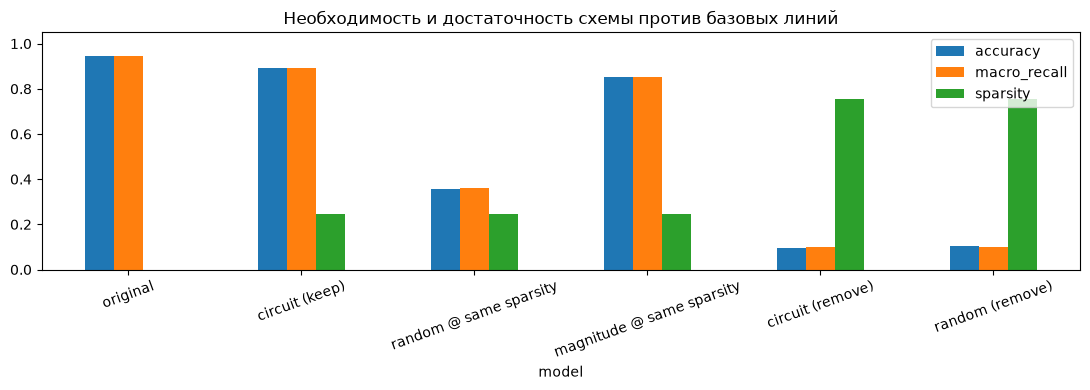

,class,stage,targets,critical,harmful,synergy_nodes,n_redundant_pairs,chosen,stopped
0,0,fc1 -> fc2,"(0,)","[2, 4, 5, 7, 8, 13, 14, 15, 18, 20]","[0, 1, 6, 9, 16, 19, 21]",[],0,"[2, 4, 5, 7, 8, 13, 14, 15, 18, 20]",False
1,0,conv2 -> fc1,"(2, 4, 5, 7, 8, 13, 14, 15, 18, 20)","[0, 2, 3, 4, 5, 6, 7, 8, 9]",[],[],1,"[0, 2, 3, 4, 5, 6, 7, 8, 9]",False
2,0,conv1 -> conv2,"(0, 2, 3, 4, 5, 6, 7, 8, 9)","[0, 1, 2, 3, 4, 5]",[],"[0, 1, 2, 3, 4, 5]",6,"[0, 1, 2, 3, 4, 5]",False
3,1,fc1 -> fc2,"(1,)","[0, 5, 6, 7, 8, 13, 16, 17, 18, 19, 21]","[1, 2, 4, 9, 14, 15, 20, 23]",[],0,"[0, 5, 6, 7, 8, 13, 16, 17, 18, 19, 21]",False
4,1,conv2 -> fc1,"(0, 5, 6, 7, 8, 13, 16, 17, 18, 19, 21)","[0, 3, 4, 5, 6, 7, 8, 9]",[2],"[3, 4, 5, 7, 8]",3,"[0, 3, 4, 5, 6, 7, 8, 9]",False
5,1,conv1 -> conv2,"(0, 3, 4, 5, 6, 7, 8, 9)","[0, 1, 2, 3, 4, 5]",[],"[0, 1, 2, 3, 4, 5]",6,"[0, 1, 2, 3, 4, 5]",False
6,2,fc1 -> fc2,"(2,)","[5, 6, 8, 9, 14, 15, 17, 19, 20]","[1, 2, 4, 7, 13, 16, 18, 21, 23]",[],0,"[5, 6, 8, 9, 14, 15, 17, 19, 20]",False
7,2,conv2 -> fc1,"(5, 6, 8, 9, 14, 15, 17, 19, 20)","[0, 2, 3, 4, 5, 6, 7, 8, 9]",[],[],0,"[0, 2, 3, 4, 5, 6, 7, 8, 9]",False
8,2,conv1 -> conv2,"(0, 2, 3, 4, 5, 6, 7, 8, 9)","[0, 1, 2, 3, 5]",[4],"[0, 1]",4,"[0, 1, 2, 3, 5]",False
9,3,fc1 -> fc2,"(3,)","[0, 1, 2, 4, 6, 7, 9, 13, 15, 16, 17, 20]","[5, 8, 14, 18, 19, 21, 23]",[],0,"[0, 1, 2, 4, 6, 7, 9, 13, 15, 16, 17, 20]",False


In [4]:
# 4. Маскирование circuits: необходимость, достаточность и базовые линии при той же разреженности
LAYERS = ['conv1', 'conv2', 'fc1', 'fc2']

def masks_from_results(results, key='chosen'):
    """mask = 1 на путях, входящих в схему. Слои, до которых top-down не дошёл,
    остаются полностью единичными: иначе досрочный break обнулял бы сеть целиком."""
    masks = {name: torch.zeros_like(module_of(model, name).weight) for name in LAYERS}
    touched = {name: False for name in LAYERS}
    for res in results.values():
        for stage in res['stages']:
            chosen = stage[key]
            child, targets, block = stage['child'], list(stage['targets']), stage['block']
            if targets: touched[child] = True
            for source in chosen:
                if block is None: masks[child][targets, source] = 1
                else:             masks[child][targets, source * block:(source + 1) * block] = 1
            if stage['parent'] == 'conv1' and chosen:
                touched['conv1'] = True
                masks['conv1'][chosen] = 1   # conv1 - вход сети, маскируется целыми фильтрами
    for name in LAYERS:
        if not touched[name]:
            print(f'[предупреждение] слой {name} не был затронут отбором, маскирование пропущено')
            masks[name] = torch.ones_like(masks[name])
        elif masks[name].count_nonzero() == 0:
            print(f'[предупреждение] в слое {name} не отобрано ни одного пути: '
                  f'маскированная модель будет вырожденной, строки сравнения читать нельзя')
    return masks

@torch.no_grad()
def apply_mask(net, masks, mode='keep'):
    """mode='keep' - оставить только схему (достаточность);
       mode='remove' - удалить схему, оставить остальное (необходимость)."""
    out = deepcopy(net).eval()
    for name, mask in masks.items():
        m = mask if mode == 'keep' else (1.0 - mask)
        layer = module_of(out, name)
        layer.weight.mul_(m.to(layer.weight.device))
        # У узла без оставшихся входов bias не должен создавать ложную активацию.
        if layer.bias is not None:
            alive = (m.flatten(1).sum(1) > 0).to(layer.bias.dtype).to(layer.bias.device)
            layer.bias.mul_(alive)
    return out.to(device)

def random_mask_like(masks, seed=SEED):
    g = torch.Generator().manual_seed(seed); out = {}
    for name, m in masks.items():
        k = int(m.count_nonzero()); flat = torch.zeros(m.numel())
        flat[torch.randperm(m.numel(), generator=g)[:k]] = 1
        out[name] = flat.view_as(m).to(m.device)
    return out

def magnitude_mask_like(masks, net=None):
    net = net or model; out = {}
    for name, m in masks.items():
        k = int(m.count_nonzero())
        w = module_of(net, name).weight.detach().abs().flatten().cpu()
        flat = torch.zeros_like(w)
        if k > 0: flat[torch.topk(w, k).indices] = 1
        out[name] = flat.view_as(m).to(m.device)
    return out

@torch.no_grad()
def metrics(net):
    correct = total = 0; per_class_correct = torch.zeros(10); per_class_total = torch.zeros(10)
    for xb, yb in test_loader:
        pred = net(xb.to(device)).argmax(1).cpu(); correct += (pred == yb).sum().item(); total += len(yb)
        for c in range(10):
            m = yb == c; per_class_correct[c] += (pred[m] == c).sum(); per_class_total[c] += m.sum()
    recall = per_class_correct / per_class_total.clamp_min(1)
    return {'accuracy': correct / total, 'macro_recall': recall.mean().item(),
            **{f'recall_{c}': recall[c].item() for c in range(10)}}

def sparsity(masks, mode='keep'):
    kept = sum(m.count_nonzero().item() for m in masks.values())
    total = sum(m.numel() for m in masks.values())
    return 1 - kept / total if mode == 'keep' else kept / total

backbone_masks = masks_from_results(results, key='chosen')
rand_masks = random_mask_like(backbone_masks)
mag_masks = magnitude_mask_like(backbone_masks)

rows = [
    {'model': 'original',                'test': 'none',         'sparsity': 0.0, **metrics(model)},
    {'model': 'circuit (keep)',          'test': 'sufficiency',  'sparsity': sparsity(backbone_masks, 'keep'),
     **metrics(apply_mask(model, backbone_masks, 'keep'))},
    {'model': 'random @ same sparsity',  'test': 'sufficiency',  'sparsity': sparsity(rand_masks, 'keep'),
     **metrics(apply_mask(model, rand_masks, 'keep'))},
    {'model': 'magnitude @ same sparsity','test': 'sufficiency', 'sparsity': sparsity(mag_masks, 'keep'),
     **metrics(apply_mask(model, mag_masks, 'keep'))},
    {'model': 'circuit (remove)',        'test': 'necessity',    'sparsity': sparsity(backbone_masks, 'remove'),
     **metrics(apply_mask(model, backbone_masks, 'remove'))},
    {'model': 'random (remove)',         'test': 'necessity',    'sparsity': sparsity(rand_masks, 'remove'),
     **metrics(apply_mask(model, rand_masks, 'remove'))},
]
comparison = pd.DataFrame(rows)
display(comparison[['model', 'test', 'sparsity', 'accuracy', 'macro_recall']].round(4))
display(comparison.set_index('model')[[f'recall_{c}' for c in range(10)]].round(3))

ax = comparison.set_index('model')[['accuracy', 'macro_recall', 'sparsity']].plot.bar(
    rot=20, figsize=(11, 4), ylim=(0, 1.05), title='Необходимость и достаточность схемы против базовых линий')
plt.tight_layout(); plt.show()

# Таблица аудита: какие цели и какие нейроны были оставлены на каждом шаге.
audit = pd.DataFrame([{'class': c, 'stage': f"{s['parent']} -> {s['child']}", 'targets': str(s['targets']),
                       'critical': str(s['critical']), 'harmful': str(s['harmful']),
                       'synergy_nodes': str(s['synergy_nodes']),
                       'n_redundant_pairs': len(s['redundant_pairs']),
                       'chosen': str(s['chosen']), 'stopped': s['stopped']}
                      for c, r in results.items() for s in r['stages']])
display(audit)

## Прунинг, учитывающий избыточность

Стандартные критерии прунинга (магнитуда, Тейлор, SNIP) оценивают каждую единицу независимо и затем удаляют лучшие $k$. Такой критерий по построению слеп к измеренному здесь взаимодействию: два взаимно избыточных канала оба получают низкий индивидуальный ущерб, потому что каждый компенсируется другим, и одношаговый критерий удаляет оба сразу, теряя механизм целиком. Статистика знаков $S$ из предыдущей ячейки показывает, насколько часто такая ситуация вообще встречается в этой сети.

Жадная процедура использует динамическое измерение ущерба. Единицей прунинга считается канал или нейрон вместе со всеми его исходящими путями. На каждом шаге перебираются все оставшиеся единицы, измеряется фактический ущерб **на уже прореженной сети**, и удаляется наименее вредная. Повторное измерение учитывает зависимости между удалениями: после удаления одного из пары избыточных каналов ущерб от удаления второго может существенно возрасти. Такой подход учитывает взаимодействия любого порядка при выборе порядка удаления, но не оценивает коэффициенты взаимодействия напрямую.

Сравниваются три порядка удаления при одинаковом бюджете:

* `greedy` - жадный с перезамером (предлагаемый);
* `one-shot` - тот же ущерб, но измеренный один раз на полной сети и отсортированный (аналог Тейлор-критерия);
* `magnitude` - норма исходящих весов единицы.

Порядок выбирается по calibration split, качество измеряется на нетронутом test split. Если жадный порядок сохраняет точность дольше одношаговых критериев, это свидетельствует о практической пользе повторного измерения ущерба. Дополнительно оценивается согласованность между ранними удалениями и парами, помеченными как избыточные.

greedy   : [('fc1', 3), ('fc1', 10), ('fc1', 11), ('fc1', 12), ('fc1', 22), ('conv2', 1), ('fc1', 7), ('conv1', 2), ('fc1', 8), ('conv1', 1), ('fc1', 0), ('fc1', 23), ('conv2', 7), ('fc1', 17), ('fc1', 19), ('conv2', 2), ('conv1', 3), ('fc1', 1), ('conv2', 8), ('fc1', 13)]
one-shot : [('fc1', 3), ('fc1', 10), ('fc1', 11), ('fc1', 12), ('fc1', 22), ('conv2', 1), ('fc1', 7), ('conv1', 2), ('fc1', 8), ('conv1', 1), ('fc1', 0), ('conv2', 8), ('conv1', 5), ('fc1', 1), ('conv2', 9), ('fc1', 16), ('conv2', 2), ('fc1', 17), ('fc1', 23), ('fc1', 19)]
magnitude: [('fc1', 22), ('fc1', 12), ('fc1', 3), ('fc1', 11), ('fc1', 9), ('fc1', 14), ('fc1', 10), ('fc1', 0), ('fc1', 2), ('fc1', 23), ('fc1', 20), ('fc1', 6), ('fc1', 1), ('fc1', 13), ('fc1', 7), ('fc1', 16), ('fc1', 19), ('fc1', 8), ('fc1', 15), ('fc1', 21)]


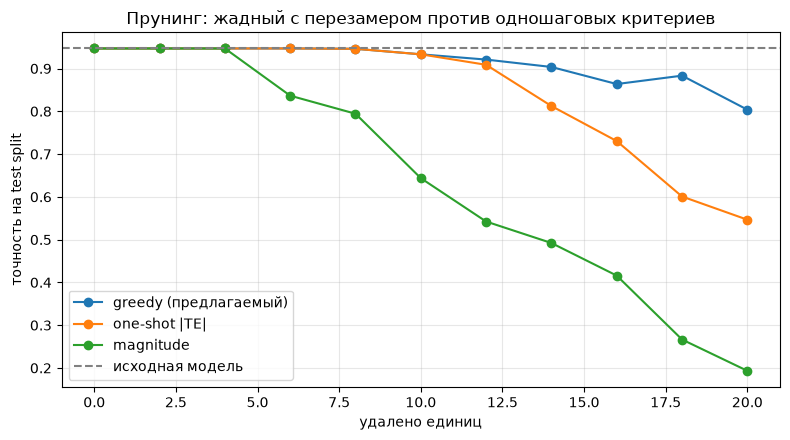

,greedy (предлагаемый),one-shot |TE|,magnitude
removed,,,
0,0.9469,0.9469,0.9469
2,0.9469,0.9469,0.9469
4,0.9469,0.9469,0.9469
6,0.9469,0.9469,0.8365
8,0.9461,0.9461,0.7943
10,0.9332,0.9332,0.6437
12,0.9209,0.9087,0.5423
14,0.9036,0.8123,0.4921
16,0.8637,0.7304,0.4159



Пар из первых 8 удалений, помеченных как избыточные: 0 из 28


In [5]:
# 5. Прунинг с учётом избыточности: жадное удаление с перезамером
# Единица прунинга = канал/нейрон со всеми исходящими путями.
UNITS = ([('fc1', j) for j in range(24)] +
         [('conv2', c) for c in range(10)] +
         [('conv1', c) for c in range(6)])

def outgoing_index(unit):
    layer, i = unit
    if layer == 'fc1':   return 'fc2', (slice(None), i)
    if layer == 'conv2': return 'fc1', (slice(None), slice(i * 16, (i + 1) * 16))
    if layer == 'conv1': return 'conv2', (slice(None), i)
    raise ValueError(layer)

@torch.no_grad()
def net_without(units, base=None):
    net = deepcopy(model if base is None else base).eval()
    for u in units:
        child, idx = outgoing_index(u)
        module_of(net, child).weight[idx] = 0
    return net.to(device)

cal_x = x_train[cal_idx][:2000]; cal_y = y_train[cal_idx][:2000]
@torch.no_grad()
def cal_acc(net):
    return (net(cal_x.to(device)).argmax(1).cpu() == cal_y).float().mean().item()

BUDGET = 20  # сколько единиц удаляем максимум

def greedy_order(budget=BUDGET):
    """Перезамер после каждого шага: как только один из пары избыточных единиц удалён,
    ущерб от удаления второго перестаёт быть малым, и жадный критерий его не берёт."""
    removed, remaining, order = [], list(UNITS), []
    for _ in range(budget):
        best, best_acc = None, -1.0
        for u in remaining:
            a = cal_acc(net_without(removed + [u]))
            if a > best_acc: best_acc, best = a, u
        order.append(best); removed.append(best); remaining.remove(best)
    return order

solo_acc = {u: cal_acc(net_without([u])) for u in UNITS}
oneshot_order = sorted(UNITS, key=lambda u: -solo_acc[u])[:BUDGET]

def out_norm(u):
    child, idx = outgoing_index(u)
    return module_of(model, child).weight[idx].norm().item()
magnitude_order = sorted(UNITS, key=out_norm)[:BUDGET]

greedy = greedy_order()
print('greedy   :', greedy)
print('one-shot :', oneshot_order)
print('magnitude:', magnitude_order)

STEP = 2
ks = list(range(0, BUDGET + 1, STEP))
curves = {name: [metrics(net_without(order[:k]))['accuracy'] for k in ks]
          for name, order in [('greedy (предлагаемый)', greedy),
                              ('one-shot |TE|', oneshot_order),
                              ('magnitude', magnitude_order)]}
plt.figure(figsize=(8, 4.5))
for name, ys in curves.items(): plt.plot(ks, ys, marker='o', label=name)
plt.axhline(metrics(model)['accuracy'], ls='--', c='gray', label='исходная модель')
plt.xlabel('удалено единиц'); plt.ylabel('точность на test split')
plt.title('Прунинг: жадный с перезамером против одношаговых критериев')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
display(pd.DataFrame(curves, index=pd.Index(ks, name='removed')).round(4))

# Согласованность: попадают ли ранние удаления жадного порядка в избыточные пары.
red = {(s['parent'], a, b) for r in results.values() for s in r['stages'] for a, b in s['redundant_pairs']}
first = greedy[:8]
hits = [(u, v) for u, v in combinations(first, 2)
        if u[0] == v[0] and ((u[0], min(u[1], v[1]), max(u[1], v[1])) in red)]
print(f'\nПар из первых 8 удалений, помеченных как избыточные: {len(hits)} из {len(list(combinations(first, 2)))}')
for h in hits[:10]: print('  ', h)

## Устойчивость по seed

Все выводы выше получены на одной обученной сети. Доля избыточных и комплементарных пар зависит от того, насколько сеть переобучена и насколько велик запас ёмкости, поэтому единственный seed не позволяет утверждать ничего о распространённости взаимодействий. Ниже анализ повторяется на нескольких seed, и выводится только агрегированная статистика знаков: это тот показатель, на который опирается предлагаемый критерий прунинга.

Разброс между seed следует приводить в тексте работы наравне со средним. Если доля избыточных пар варьируется в разы, вывод о применимости критерия к другим сетям не обоснован.

In [6]:
# 6. Повтор анализа на нескольких seed: устойчивость статистики знаков
SEEDS = [42, 0, 1]          # увеличить при наличии времени
SEED_CLASSES = list(range(10))

seed_rows = []
for s in SEEDS:
    net_s = build_and_train(s, verbose=False)
    res_s = {c: infer_class(net_s, c, target_mode='active') for c in SEED_CLASSES}
    pairs_s = pd.DataFrame([r for res in res_s.values() for r in res['pairs']])
    nodes_s = pd.DataFrame([r for res in res_s.values() for r in res['nodes']])
    row = {'seed': s, 'test_acc': metrics(net_s.to(device))['accuracy'],
           'n_pairs': len(pairs_s),
           'critical_share': float((nodes_s.role == 'critical').mean()),
           'harmful_share': float((nodes_s.role == 'harmful').mean())}
    for sign in ['complementary', 'redundant', 'additive']:
        row[f'{sign}_share'] = float((pairs_s.sign == sign).mean()) if len(pairs_s) else float('nan')
    seed_rows.append(row); print(row)

seed_table = pd.DataFrame(seed_rows)
display(seed_table.round(4))
print('\nСреднее и стандартное отклонение по seed:')
display(seed_table.drop(columns='seed').agg(['mean', 'std']).round(4))

{'seed': 42, 'test_acc': 0.9469, 'n_pairs': 600, 'critical_share': 0.6075, 'harmful_share': 0.215, 'complementary_share': 0.08, 'redundant_share': 0.09833333333333333, 'additive_share': 0.8216666666666667}
{'seed': 0, 'test_acc': 0.9387, 'n_pairs': 600, 'critical_share': 0.58, 'harmful_share': 0.205, 'complementary_share': 0.043333333333333335, 'redundant_share': 0.055, 'additive_share': 0.9016666666666666}
{'seed': 1, 'test_acc': 0.944, 'n_pairs': 600, 'critical_share': 0.6175, 'harmful_share': 0.1875, 'complementary_share': 0.07666666666666666, 'redundant_share': 0.125, 'additive_share': 0.7983333333333333}


,seed,test_acc,n_pairs,critical_share,harmful_share,complementary_share,redundant_share,additive_share
0,42,0.9469,600,0.6075,0.2150,0.0800,0.0983,0.8217
1,0,0.9387,600,0.5800,0.2050,0.0433,0.0550,0.9017
2,1,0.9440,600,0.6175,0.1875,0.0767,0.1250,0.7983



Среднее и стандартное отклонение по seed:


,test_acc,n_pairs,critical_share,harmful_share,complementary_share,redundant_share,additive_share
mean,0.9432,600.0,0.6017,0.2025,0.0667,0.0928,0.8406
std,0.0042,0.0,0.0194,0.0139,0.0203,0.0353,0.0542


## Краткий вывод

На данном запуске исходная Tiny-LeNet достигает accuracy 0.9469. Causal backbone сохраняет accuracy 0.8935 при разреженности 0.2436, превосходя маску по магнитуде весов (0.8529) и случайную маску той же плотности (0.3577). Следовательно, в этой модели отобранные path-группы содержат существенно больше функционально релевантной информации, чем неструктурированный набор весов той же численности.

Парный анализ выявил неаддитивные взаимодействия преимущественно на переходе `conv1 -> conv2`: для seed 42 обнаружены 42 комплементарные и 48 избыточных пары из 150. На переходе `conv2 -> fc1` таких пар существенно меньше: 6 и 11 из 450 соответственно. По трём seed доли комплементарных и избыточных пар составили 0.0667 ± 0.0203 и 0.0928 ± 0.0353, поэтому наличие парных взаимодействий воспроизводится, тогда как их точная распространённость зависит от инициализации.

Проверка необходимости пока не отделяет эффект causal circuit от эффекта сильного удаления параметров: после удаления схемы и после сопоставимого случайного удаления accuracy близка к случайному уровню. Жадный прунинг с повторным измерением сохраняет 0.8038 accuracy после удаления 20 единиц, тогда как одношаговый критерий сохраняет 0.5466; это демонстрирует практическую ценность адаптивного перезамера, но не подтверждает прямую связь его решений с найденными redundant-парами. Выводы относятся к фиксированной Tiny-LeNet и парным внутри-слоевым вмешательствам; для ResNet-18 и взаимодействий более высокого порядка потребуются структурированные baseline, ограниченный набор кандидатов и дополнительные групповые интервенции.